In [44]:
import torch
import numpy as np
import os
import pickle
import sys
import argparse
import matplotlib.pyplot as plt
from copy import deepcopy
from itertools import repeat
from tqdm import tqdm
from einops import rearrange
from torchvision import transforms

from constants import FPS
from constants import PUPPET_GRIPPER_JOINT_OPEN
from utils import load_data # data functions
from utils import sample_box_pose, sample_insertion_pose # robot functions
from utils import compute_dict_mean, set_seed, detach_dict, calibrate_linear_vel, postprocess_base_action # helper functions
from policy import ACTPolicy, CNNMLPPolicy, DiffusionPolicy
from visualize_episodes import save_videos

from detr.models.latent_model import Latent_Model_Transformer

from sim_env import BOX_POSE

from imitate_episodes import forward_pass, make_policy, repeater
from constants import SIM_TASK_CONFIGS as TASK_CONFIGS

In [40]:
# adjustable parameters
dataset_dir = ' /scr/zach/blue_needle_filtered'
ckpt_dir = '/iris/u/zachwitz/act-plus-plus/ckpt/ACT_aloha_thread_blue_needle_glue_1_22_09_2024_03_07_14/'
task_name = 'aloha_thread_blue_needle_glue'
task_config = TASK_CONFIGS[task_name]
policy_class = 'ACT'
chunk_size = 100
lr = 1e-4

# from task config
dataset_dir = task_config['dataset_dir']
episode_len = task_config['episode_len']
camera_names = task_config['camera_names']
stats_dir = task_config.get('stats_dir', None)
sample_weights = task_config.get('sample_weights', None)
train_ratio = task_config.get('train_ratio', 0.99)
name_filter = task_config.get('name_filter', lambda n: True)

# fixed parameters
enc_layers = 4
dec_layers = 7
nheads = 8
lr = 1e-5
policy_config = {
    'lr': lr,
    'num_queries': chunk_size,
    'kl_weight': 10,
    'hidden_dim': 256,
    'dim_feedforward': 2048,
    'lr_backbone': lr,
    'backbone': 'resnet18',
    'enc_layers': enc_layers,
    'dec_layers': dec_layers,
    'nheads': nheads,
    'camera_names': camera_names,
    'vq': False,
    'vq_class': '',
    'vq_dim': 0,
    'action_dim': 16,
    'no_encoder': False,
    'fine_tune_last_layers': False,
}

In [31]:
train_dataloader, _, stats, _ = load_data(dataset_dir, name_filter, camera_names, 8, 8, chunk_size, False, False, policy_class, stats_dir_l=stats_dir, sample_weights=sample_weights, train_ratio=train_ratio)
train_dataloader = repeater(train_dataloader)

Found 51 hdf5 files


Data from: ['/scr/optometrists//aloha_thread_blue_needle_glue']
- Train on [50] episodes
- Test on [1] episodes


Found 51 hdf5 files
Norm stats from: ['/scr/optometrists//aloha_thread_blue_needle_glue']
Initializing transformations
Initializing transformations
Augment images: False, train_num_workers: 2, val_num_workers: 2


[]

In [43]:
# we need to override the jupyter system arguments so we can execute the detr main file
sys.argv = ['notebook', '--ckpt_dir', ckpt_dir, '--policy_class', policy_class, '--task_name', task_name, '--seed', '0', '--num_steps', '100']
policy = make_policy(policy_class, policy_config)

Use VQ: False, , 0
number of parameters: 66.44M
KL Weight 10


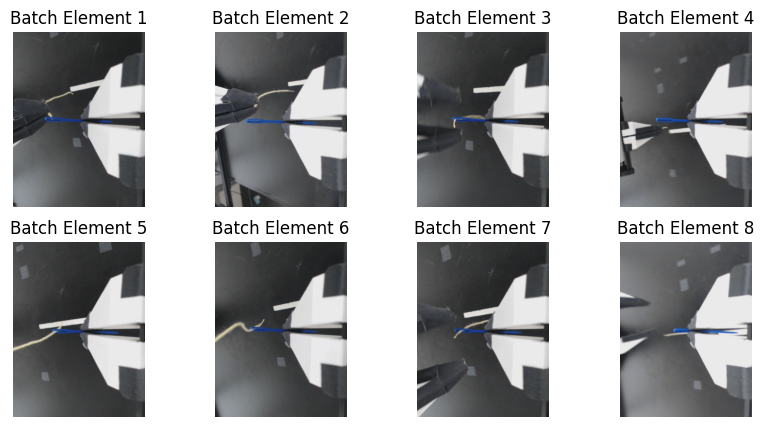

In [24]:
# Rerun this cell to sample a new batch

# find an image from the insertion point
data = next(train_dataloader)

images, _, _, _ = data
# Set up the plot: 2 rows and 4 columns (because we have 8 images)
fig, axes = plt.subplots(2, 4, figsize=(10, 5))

# Loop over each image and show it in the appropriate subplot
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i,1].T)
    ax.set_title(f"Batch Element {i+1}")  # Set title as "Batch Element {I}"
    ax.axis('off')  # Hide axes for cleaner display

In [64]:
policy.eval()
data = next(train_dataloader)

In [58]:
image_data, qpos_data, action_data, is_pad = data
image_data, qpos_data, action_data, is_pad = image_data.cuda(), qpos_data.cuda(), action_data.cuda(), is_pad.cuda()

post_process = lambda a: a * stats['action_std'] + stats['action_mean']

In [79]:
action = policy(qpos_data, image_data)[:,:,:-2]

In [82]:
normalized_left_gripper_action = action[:,:,6]
normalized_right_gripper_action = action[:,:,7+6]

In [93]:
post_process(policy(qpos_data, image_data)[0].detach().cpu().numpy())[:,7+6]

array([0.04316871, 0.05739292, 0.05478747, 0.03967361, 0.04228711,
       0.04851738, 0.05287655, 0.05207928, 0.05003277, 0.04788613,
       0.04923026, 0.04062327, 0.04663672, 0.04465813, 0.0500078 ,
       0.04831122, 0.05244903, 0.05108431, 0.05085749, 0.05113938,
       0.04864864, 0.05360457, 0.04449351, 0.04792396, 0.05273517,
       0.05299012, 0.05648699, 0.04307234, 0.04164845, 0.04150541,
       0.04947316, 0.04644991, 0.04990003, 0.04637138, 0.04462323,
       0.04739124, 0.05324341, 0.05181196, 0.0444374 , 0.04423487,
       0.05006856, 0.03969754, 0.04429104, 0.05674426, 0.04738127,
       0.04647448, 0.05442756, 0.05150932, 0.04717235, 0.04543892,
       0.05782715, 0.04543076, 0.05694342, 0.04821816, 0.04993793,
       0.05388836, 0.05327745, 0.04997232, 0.05438347, 0.05613118,
       0.05995425, 0.05104101, 0.04872294, 0.05252431, 0.04771145,
       0.04808944, 0.04936485, 0.0567961 , 0.05462144, 0.04063128,
       0.04948557, 0.04692443, 0.05131299, 0.04628383, 0.05328

In [88]:
post_process(normalized_right_gripper_action[0].detach().cpu().numpy())

ValueError: operands could not be broadcast together with shapes (100,) (16,) 